# Dengue Brasil

### Introdução

A dengue faz parte de um grupo de doenças denominadas arboviroses, que se caracterizam por serem causadas por vírus transmitidos por vetores artrópodes. No Brasil, o vetor da dengue é a fêmea do mosquito Aedes aegypti (significa "odioso do Egito"). Os vírus dengue (DENV) estão classificados cientificamente na família Flaviviridae e no gênero Flavivirus. Até o momento são conhecidos quatro sorotipos – DENV-1, DENV-2, DENV-3 e DENV-4 –, que apresentam distintos materiais genéticos (genótipos) e linhagens.<br/>

As evidências apontam que o mosquito tenha vindo nos navios que partiam da África com escravos. No Brasil, a primeira epidemia documentada clínica e laboratorialmente ocorreu em 1981-1982, em Boa Vista (RR), causada pelos sorotipos 1 e 4. Após quatro anos, em 1986, ocorreram epidemias atingindo o estado do Rio de Janeiro e algumas capitais da região Nordeste. Desde então, a dengue vem ocorrendo de forma continuada (endêmica), intercalando-se com a ocorrência de epidemias, geralmente associadas à introdução de novos sorotipos em áreas indenes (sem transmissão) e/ou alteração do sorotipo predominante, acompanhando a expansão do mosquito vetor.<br/>

Aspectos como a urbanização, o crescimento desordenado da população, o saneamento básico deficitário e os fatores climáticos mantêm as condições favoráveis para a presença do vetor, com reflexos na dinâmica de transmissão desses arbovírus. A dengue possui padrão sazonal, com aumento do número de casos e o risco para epidemias, principalmente entre os meses de outubro de um ano a maio do ano seguinte.

### Sinais e sintomas
A dengue é uma doença febril aguda, sistêmica, dinâmica, debilitante e autolimitada. A maioria dos doentes se recupera, porém, parte deles podem progredir para formas graves, inclusive virem a óbito. A quase totalidade dos óbitos por dengue é evitável e depende, na maioria das vezes, da qualidade da assistência prestada e organização da rede de serviços de saúde.
Todo indivíduo que apresentar febre (39°C a 40°C) de início repentino e apresentar pelo menos duas das seguintes manifestações - dor de cabeça, prostração, dores musculares e/ou articulares e dor atrás dos olhos – deve procurar imediatamente um serviço de saúde, a fim de obter tratamento oportuno.


### Taxa de incidência de dengue <br/>
http://tabnet.datasus.gov.br/tabdata/LivroIDB/2edrev/d0203.pdf

In [1]:
# Libs importantes

# Manipulação de Dados
import pandas as pd
import numpy as np

# Visualização dos Dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df_dengue = pd.read_excel('Base de Dados Dengue.xlsx')

In [3]:
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3


In [4]:
df_dengue.tail()

,municipio,uf,data_infeccoes,qtd_infeccoes
728767,BRASILIA,DF,2023-08-01,939
728768,BRASILIA,DF,2023-09-01,843
728769,BRASILIA,DF,2023-10-01,686
728770,BRASILIA,DF,2023-11-01,1300
728771,BRASILIA,DF,2023-12-01,5603


## Explorando o dataset

In [5]:
print(f'Tamanho do nosso Dataset: {df_dengue.shape}')

Tamanho do nosso Dataset: (728772, 4)


In [6]:
# Características (tipo) da coluna
df_dengue.dtypes

,0
municipio,object
uf,object
data_infeccoes,datetime64[ns]
qtd_infeccoes,int64


In [7]:
# Existe valores nulos?

#Para ser mais eficiente, principalmente para tabelas grandes, utiliza a soma de quantidade de valores que são true
df_dengue.isnull().sum()

,0
municipio,0
uf,0
data_infeccoes,0
qtd_infeccoes,0


In [8]:
print(f'Quantidade de dados nulos: {df_dengue.isnull().sum().sum()}')

Quantidade de dados nulos: 0


In [9]:
#Informações sobre a base

df_dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728772 entries, 0 to 728771
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   municipio       728772 non-null  object        
 1   uf              728772 non-null  object        
 2   data_infeccoes  728772 non-null  datetime64[ns]
 3   qtd_infeccoes   728772 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 22.2+ MB


Verificar os valores únicos

In [10]:
df_dengue.nunique()

,0
municipio,5243
uf,27
data_infeccoes,132
qtd_infeccoes,1157


Com estes valores, descobrimos que nem todos os munícipios tem um foco grande com a dengue, ou seja, não está apresentando na fonte de dados.

[link text](https://)## Precisamos calcular a quantidade de pessoas que pegaram dengue por munícipio por ano

In [11]:
#Criar uma cluna de ano

df_dengue ['ano'] = df_dengue['data_infeccoes'].dt.year
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes,ano
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34,2013
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44,2013
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15,2013
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4,2013
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3,2013


In [12]:
infeccoes_municipio = df_dengue.groupby(['ano', 'municipio', 'uf'])['qtd_infeccoes'].sum().reset_index()

In [13]:
infeccoes_municipio.head()

,ano,municipio,uf,qtd_infeccoes
0,2013,ABADIA DE GOIAS,GO,52
1,2013,ABADIA DOS DOURADOS,MG,0
2,2013,ABADIANIA,GO,37
3,2013,ABAETE,MG,486
4,2013,ABAETETUBA,PA,15


In [14]:
infeccoes_municipio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60731 entries, 0 to 60730
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ano            60731 non-null  int32 
 1   municipio      60731 non-null  object
 2   uf             60731 non-null  object
 3   qtd_infeccoes  60731 non-null  int64 
dtypes: int32(1), int64(1), object(2)
memory usage: 1.6+ MB


Agrupar por Estado e Ano

In [15]:
infeccoes_estado = df_dengue.groupby(['ano', 'uf'])['qtd_infeccoes'].sum().reset_index()

In [16]:
infeccoes_estado.head()

,ano,uf,qtd_infeccoes
0,2013,AC,1663
1,2013,AL,704
2,2013,AM,4327
3,2013,AP,546
4,2013,BA,13417


Estatística Descritiva

In [17]:
infeccoes_estado.describe()

,ano,qtd_infeccoes
count,297.000000,297.000000
mean,2018.000000,12872.474747
std,3.167615,31630.107741
min,2013.000000,0.000000
25%,2015.000000,780.000000
50%,2018.000000,2229.000000
75%,2021.000000,10098.000000
max,2023.000000,286000.000000


mean - média
std - desvio padrão

In [18]:
infeccoes_estado.shape

(297, 3)

<Axes: ylabel='qtd_infeccoes'>

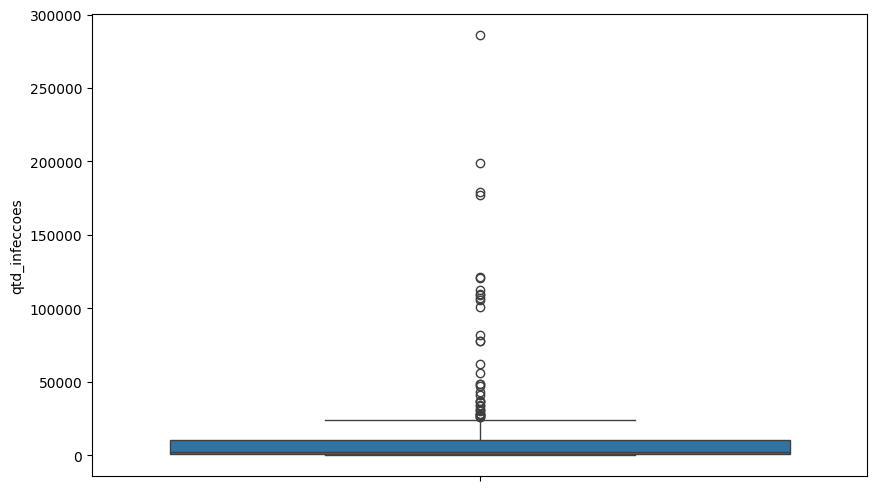

In [19]:
plt.figure(figsize= (10,6))
sns.boxplot(data = infeccoes_estado, y = 'qtd_infeccoes')

/tmp/ipykernel_2538/3572840384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = infeccoes_estado, x = 'ano', y = 'qtd_infeccoes', palette= 'viridis')


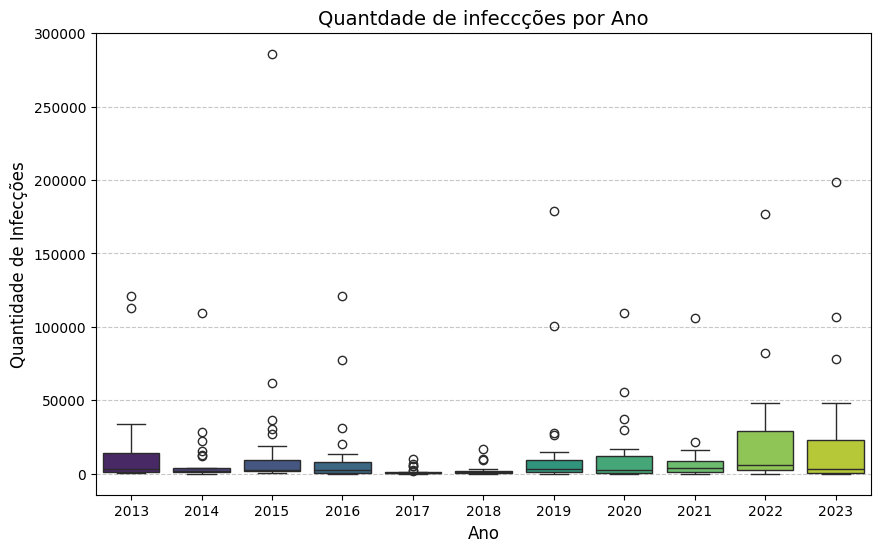

In [20]:
plt.figure(figsize= (10,6))
sns.boxplot(data = infeccoes_estado, x = 'ano', y = 'qtd_infeccoes', palette= 'viridis')

plt.title('Quantdade de infeccções por Ano', fontsize = 14)
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Quantidade de Infecções', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7 )
plt.show()

#### Interpretação
O gráfico boxplot apresenta a distribuição das infecções por ano, evidenciando uma grande variabilidade na quantidade de casos confirmados. A presença de outliers demonstra períodos em que houve surtos de grande escala, o que reforça a necessidade de um monitoramento contínuo. Os picos de infecções coincidem com eventos climáticos favoráveis à proliferação do mosquito, como temporadas de chuvas intensas.

In [21]:
#filtro de dados para o ano de 2023
infeccoes_estado_2023 = infeccoes_estado[infeccoes_estado['ano'] == 2023]
infeccoes_estado_2023

,ano,uf,qtd_infeccoes
270,2023,AC,1781
271,2023,AL,473
272,2023,AM,3263
273,2023,AP,742
274,2023,BA,13249
275,2023,CE,7437
276,2023,DF,23710
277,2023,ES,0
278,2023,GO,21682
279,2023,MA,2428


In [22]:
infeccoes_estado_2023.describe()

,ano,qtd_infeccoes
count,27.0,27.000000
mean,2023.0,22902.888889
std,0.0,43368.215001
min,2023.0,0.000000
25%,2023.0,744.000000
50%,2023.0,3263.000000
75%,2023.0,22696.000000
max,2023.0,198774.000000


/tmp/ipykernel_2538/3771844163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = infeccoes_estado_2023, y = 'qtd_infeccoes', palette= 'viridis')


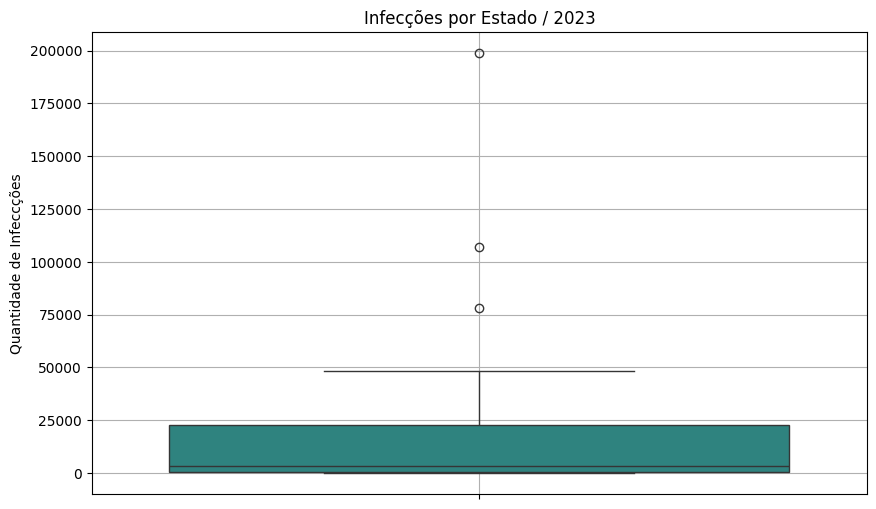

In [23]:
plt.figure(figsize= (10,6))
sns.boxplot(data = infeccoes_estado_2023, y = 'qtd_infeccoes', palette= 'viridis')
plt.title('Infecções por Estado / 2023')
plt.ylabel('Quantidade de Infeccções')
plt.grid(True)
plt.show()

In [24]:
#lib visualização plotly
import plotly.express as px

In [25]:
fig = px.box(infeccoes_estado_2023, y = 'qtd_infeccoes', title = 'Boxplot de Infeccções por Estado / 2023')
fig.show()

Comparação entre os Estados

/tmp/ipykernel_2538/3134337319.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




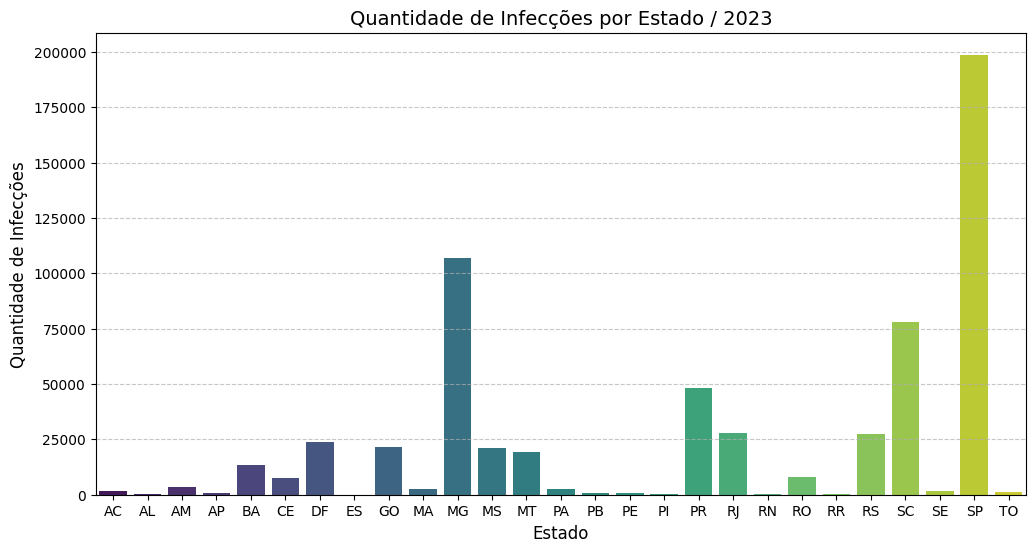

In [26]:
#Criar gráfico de barras
plt.figure(figsize= (12,6))
sns.barplot(data=infeccoes_estado_2023, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')

#Personalizar o gráfico
plt.title('Quantidade de Infecções por Estado / 2023', fontsize = 14)
plt.xlabel('Estado', fontsize = 12)
plt.ylabel('Quantidade de Infecções', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

In [27]:
#Ordenar os dados do maior para o menor

infeccoes_estado_2023.sort_values(by = 'qtd_infeccoes', ascending=False)


,ano,uf,qtd_infeccoes
295,2023,SP,198774
280,2023,MG,106923
293,2023,SC,77954
287,2023,PR,48328
288,2023,RJ,27905
292,2023,RS,27389
276,2023,DF,23710
278,2023,GO,21682
281,2023,MS,21098
282,2023,MT,19356


/tmp/ipykernel_2538/2052854287.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




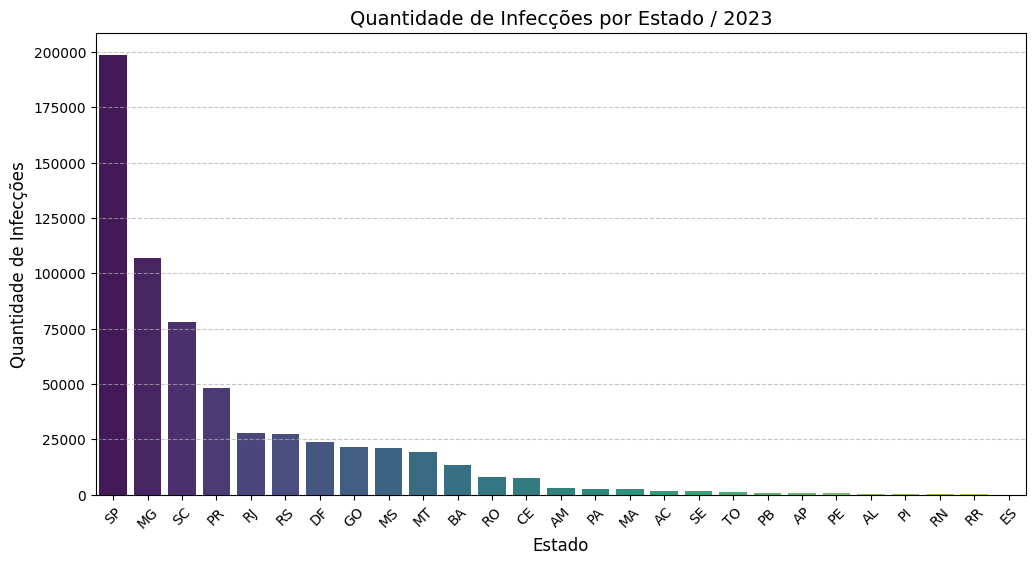

In [28]:
# COmparando os estados de forma ordenada
plt.figure(figsize= (12,6))
sns.barplot(data=infeccoes_estado_2023, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis', order = infeccoes_estado_2023.sort_values(by = 'qtd_infeccoes', ascending=False)['uf'])

#Decorar gráfico
plt.title('Quantidade de Infecções por Estado / 2023', fontsize = 14)
plt.xlabel('Estado', fontsize = 12)
plt.ylabel('Quantidade de Infecções', fontsize = 12)
plt.xticks(rotation = 45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.show()

#### Interpretação
Este gráfico mostra a quantidade de infecções confirmadas em cada estado brasileiro no ano de 2023. São Paulo, Minas Gerais e Santa Catarina lideram em número absoluto de casos, o que pode estar relacionado à alta densidade populacional e condições climáticas favoráveis ao mosquito transmissor.

Gráfico de tendências

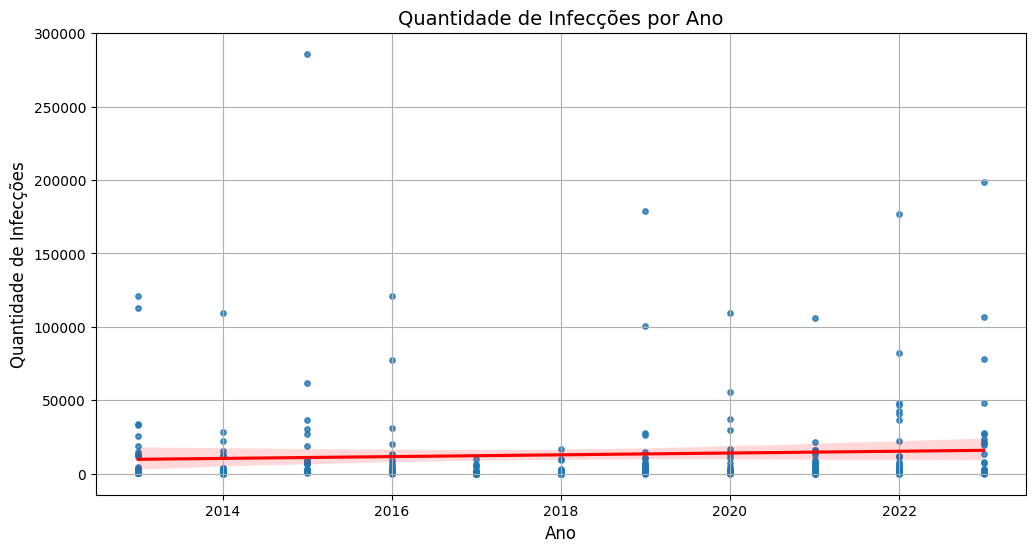

In [29]:
#Criar gráfico de tendência
plt.figure(figsize= (12,6))
sns.regplot(data = infeccoes_estado, x = 'ano', y ='qtd_infeccoes', scatter_kws={"s":15}, line_kws={"color":"red"})

#Personalizar
plt.title('Quantidade de Infecções por Ano', fontsize = 14)
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Quantidade de Infecções', fontsize = 12)
plt.grid(True)
plt.show()

#### Interpretação
A análise de tendência revela um aumento gradual no número de infecções ao longo dos anos. A linha de tendência (em vermelho) indica que, mesmo com oscilações anuais, há um padrão de crescimento sustentado, reforçando a necessidade de políticas públicas eficazes de controle e prevenção.

Conclusões e Recomendações
A análise dos dados permite responder à pergunta norteadora: Quais são as principais cidades e Estados do Brasil que têm confirmado os casos de Dengue?. Os estados de São Paulo, Minas Gerais e Santa Catarina apresentaram os maiores números de infecções confirmadas em 2023.
Com base nesses achados, recomenda-se:
Ampliação da vacinação nas regiões mais afetadas.
Fortalecimento das campanhas de prevenção.
Aprimoramento da vigilância epidemiológica.
Melhoria no saneamento básico.
Com essas medidas, é possível reduzir significativamente o impacto da Dengue e avançar na proteção da saúde pública no Brasil.


## 1. Análise de Sazonalidade: Picos de Casos de Dengue por Mês e Ano

Entender a sazonalidade da dengue é crucial para planejar ações preventivas. Vamos agrupar os casos por ano e mês para visualizar os períodos de maior incidência.

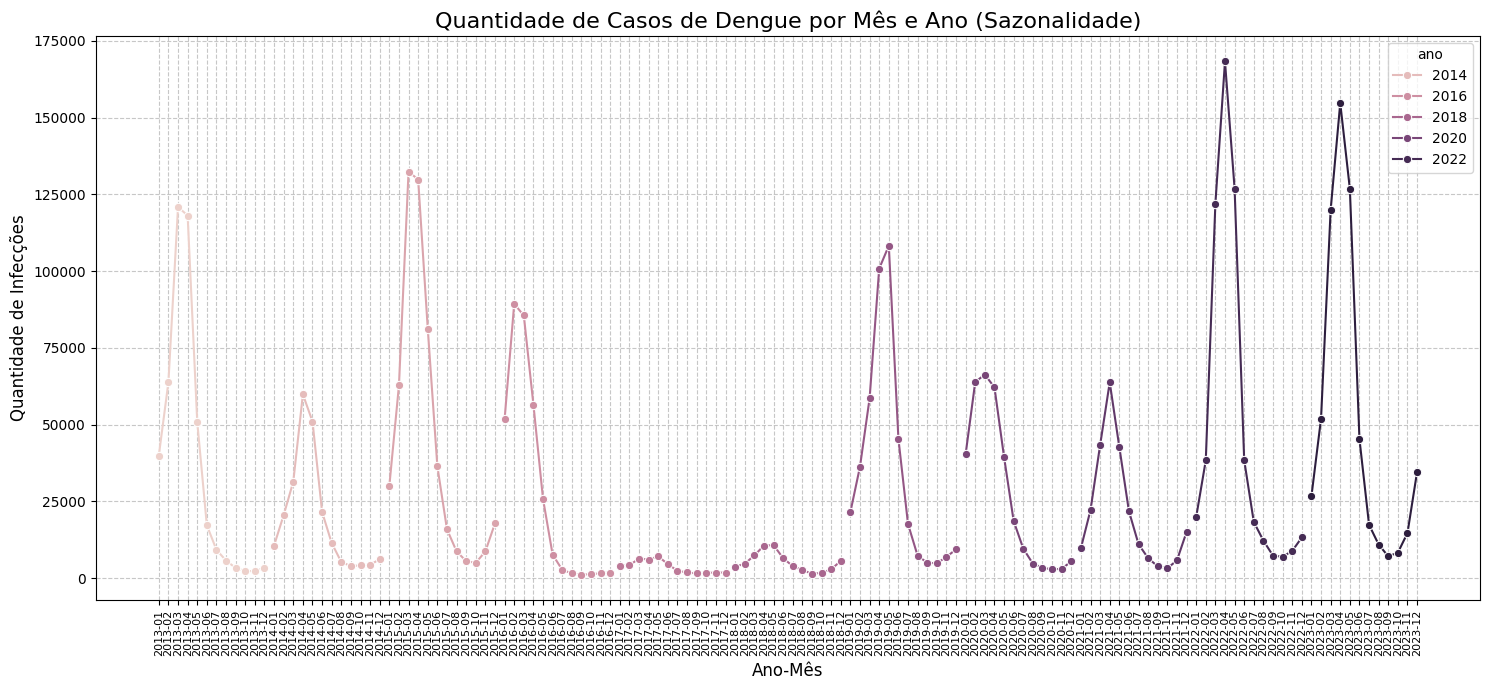


Top 5 meses com maior número de infecções (considerando todos os anos combinados):


,mes,qtd_infeccoes
3,4,930727
2,3,794198
4,5,670980
1,2,458039
5,6,263320


In [38]:

# Extrair o ano e o mês da coluna 'data_infeccoes'
df_dengue['ano'] = df_dengue['data_infeccoes'].dt.year
df_dengue['mes'] = df_dengue['data_infeccoes'].dt.month

sazonalidade_dengue = df_dengue.groupby(['ano', 'mes'])['qtd_infeccoes'].sum().reset_index()

# Para facilitar a visualização no gráfico, vamos criar uma coluna 'ano_mes', que combina o ano e o mês, garantindo a ordem cronológica
sazonalidade_dengue['ano_mes'] = sazonalidade_dengue['ano'].astype(str) + '-' + \
                                 sazonalidade_dengue['mes'].astype(str).str.zfill(2)

plt.figure(figsize=(15, 7))

# O 'x' será a coluna 'ano_mes' e o 'y' será 'qtd_infeccoes'
# 'hue' por 'ano' pode ajudar a diferenciar as linhas de cada ano
sns.lineplot(data=sazonalidade_dengue, x='ano_mes', y='qtd_infeccoes', hue='ano', marker='o')

plt.title('Quantidade de Casos de Dengue por Mês e Ano (Sazonalidade)', fontsize=16)
plt.xlabel('Ano-Mês', fontsize=12)
plt.ylabel('Quantidade de Infecções', fontsize=12)

plt.xticks(rotation=90, fontsize=8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 5 meses com maior número de infecções (considerando todos os anos combinados):")

# Para ver os meses mais críticos, podemos agrupar apenas por mês e somar
mes_critico = df_dengue.groupby('mes')['qtd_infeccoes'].sum().reset_index()
display(mes_critico.sort_values(by='qtd_infeccoes', ascending=False).head())

#### Impacto de Negócio: Planejamento Sazonal e Prevenção Estratégica

Este gráfico de sazonalidade é fundamental para que uma **prefeitura ou secretaria de saúde** possa **planejar suas ações com antecedência e de forma mais eficaz**.

*   **Alocação de Recursos Proativa:** Ao identificar que há picos de dengue em determinados meses (geralmente períodos mais quentes e chuvosos), os gestores podem antecipar a mobilização de equipes de controle de vetores, a compra de insumos essenciais (inseticidas, kits de diagnóstico) e a preparação da rede de saúde (aumento de leitos, profissionais). Isso evita a sobrecarga do sistema de saúde e os custos emergenciais de uma resposta tardia.
*   **Campanhas de Conscientização Direcionadas:** As campanhas educativas podem ser intensificadas nos meses que antecedem os picos de infecção. Informar a população sobre a eliminação de focos do mosquito e medidas preventivas nesses períodos-chave maximiza o impacto das campanhas e garante um melhor retorno sobre o investimento público.
*   **Otimização de Custos:** Ações proativas e direcionadas são significativamente mais econômicas do que as medidas reativas. A prevenção de surtos reduz a necessidade de gastos elevados com tratamento de doentes, internações e perda de produtividade da população, contribuindo para a sustentabilidade dos orçamentos públicos e privados (como planos de saúde).

## 2. Cálculo de Evolução: Crescimento Percentual de Casos Entre Anos

Para entender a dinâmica da doença e a efetividade das ações de controle, é importante analisar como o número de casos evolui ao longo do tempo. O cálculo do crescimento percentual anual nos ajuda a identificar os anos em que a situação piorou ou melhorou mais rapidamente.

Crescimento Percentual de Casos de Dengue Ano a Ano:


,ano,qtd_infeccoes,crescimento_percentual
0,2013,437104,NaN
1,2014,230178,-47.34
2,2015,534491,132.21
3,2016,326657,-38.88
4,2017,43313,-86.74
5,2018,61774,42.62
6,2019,421850,582.89
7,2020,319793,-24.19
8,2021,248910,-22.17
9,2022,580677,133.29


/tmp/ipykernel_2538/1544998449.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




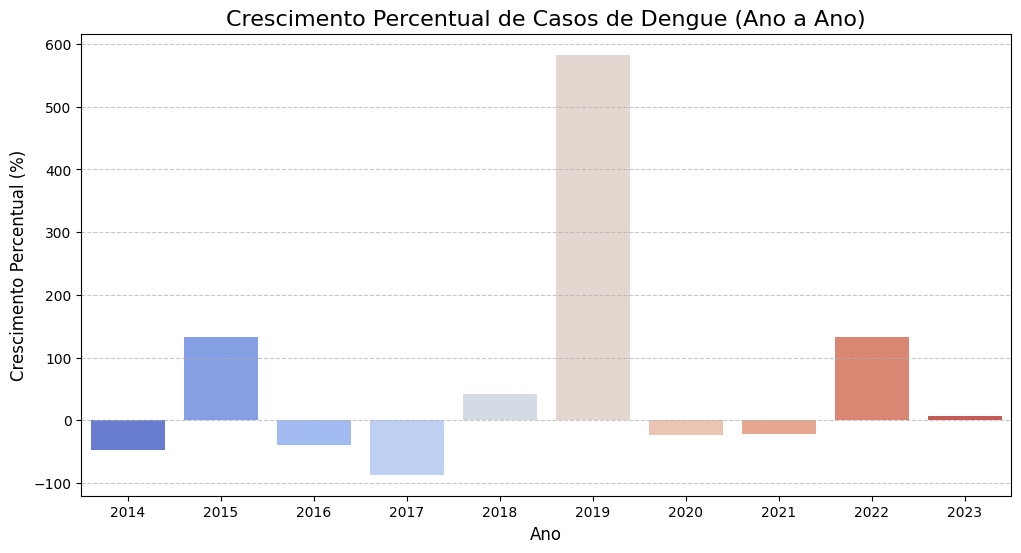

In [39]:
# Agrupar a quantidade total de infecções por ano
# Isso nos dará o número total de casos de dengue em cada ano

total_infeccoes_por_ano = df_dengue.groupby('ano')['qtd_infeccoes'].sum().reset_index()
total_infeccoes_por_ano['crescimento_percentual'] = total_infeccoes_por_ano['qtd_infeccoes'].pct_change() * 100

print("Crescimento Percentual de Casos de Dengue Ano a Ano:")
display(total_infeccoes_por_ano.round(2))

# Configurar o tamanho do gráfico
plt.figure(figsize=(12, 6))

# Criar um gráfico de barras para visualizar o crescimento percentual
sns.barplot(data=total_infeccoes_por_ano.dropna(), x='ano', y='crescimento_percentual', palette='coolwarm')

plt.title('Crescimento Percentual de Casos de Dengue (Ano a Ano)', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Crescimento Percentual (%)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Impacto de Negócio: Avaliação de Políticas Públicas e Identificação de Tendências

O crescimento percentual anual é uma métrica chave para **avaliar a efetividade das políticas públicas de combate à dengue** e identificar tendências de longo prazo na incidência da doença.

*   **Monitoramento da Efetividade de Intervenções:** Se o crescimento percentual for consistentemente alto, isso é um indicativo de que as estratégias atuais de saúde pública podem não estar sendo suficientes e precisam ser revistas. Por outro lado, se houver uma redução significativa e consistente, é um sinal de que as medidas implementadas estão funcionando e gerando resultados positivos.
*   **Tomada de Decisão Estratégica:** Essa análise permite que um **plano de saúde** preveja o aumento da demanda por atendimento médico e ajuste seus planos de cobertura e capacidade para evitar a sobrecarga. Governos podem usar esses dados para justificar a necessidade de mais investimentos em áreas críticas ou para realocar verbas de programas ineficazes.
*   **Alerta Precoce:** Um salto abrupto e inesperado no crescimento percentual pode servir como um alerta precoce para a necessidade urgente de intensificar esforços e intervenções, ajudando a evitar que um surto se transforme em uma crise sanitária de grandes proporções nos anos seguintes.

## 3. Ranking de Criticidade: Top 5 Estados com Mais Casos em 2023

Para um gestor público, é essencial saber onde concentrar os esforços limitados de saúde. Vamos identificar e visualizar os 5 estados com o maior número de casos de dengue no ano mais recente disponível (2023), que é um foco direto para a alocação de recursos.

Top 5 Estados com maior número de infecções de Dengue em 2023:


,ano,uf,qtd_infeccoes
295,2023,SP,198774
280,2023,MG,106923
293,2023,SC,77954
287,2023,PR,48328
288,2023,RJ,27905


/tmp/ipykernel_2538/2428112206.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




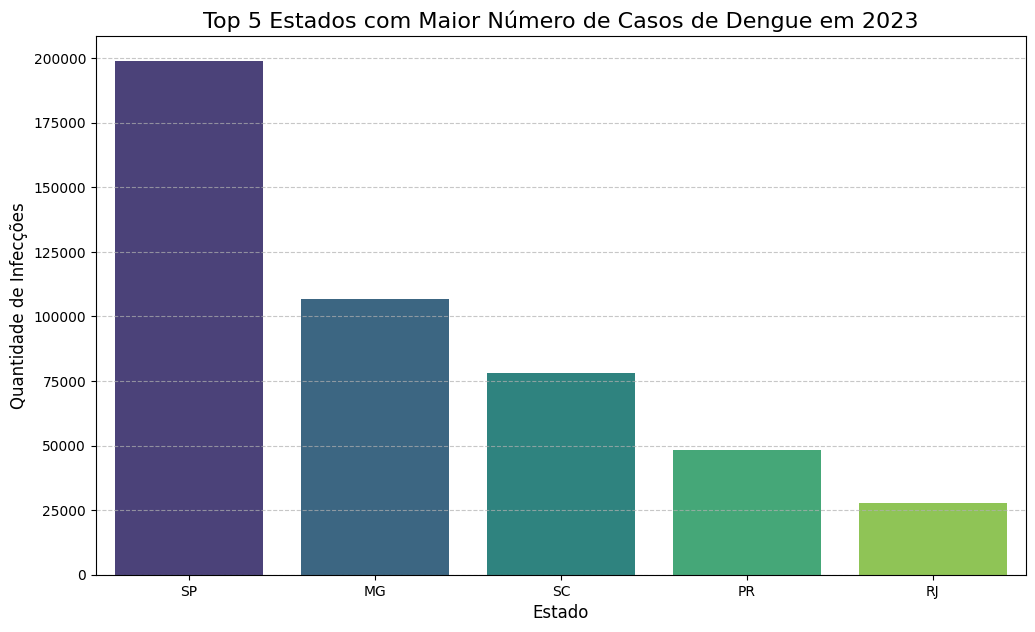

In [40]:
# Agrupar os dados por ano e UF para obter o total de infecções por estado a cada ano
infeccoes_2023 = infeccoes_estado[infeccoes_estado['ano'] == 2023]

top_5_estados = infeccoes_2023.sort_values(by='qtd_infeccoes', ascending=False).head(5)

print("Top 5 Estados com maior número de infecções de Dengue em 2023:")
display(top_5_estados)

plt.figure(figsize=(12, 7))

# O 'x' será o estado (uf) e o 'y' será a quantidade de infecções
# 'order' é importante para que as barras sejam exibidas do maior para o menor
sns.barplot(data=top_5_estados, x='uf', y='qtd_infeccoes', palette='viridis',
            order=top_5_estados['uf'])

plt.title('Top 5 Estados com Maior Número de Casos de Dengue em 2023', fontsize=16)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Quantidade de Infecções', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Impacto de Negócio: Foco Estratégico na Alocação de Recursos e Resposta Rápida

Este ranking de criticidade é uma ferramenta direta e essencial para a **tomada de decisão operacional e estratégica** de gestores públicos e de saúde. Ele indica claramente onde os recursos devem ser priorizados para combater a dengue de forma mais eficaz:

*   **Direcionamento de Ações:** Ao saber quais são os Top 5 estados mais afetados, os **exércitos de agentes de saúde** e as equipes de vigilância epidemiológica podem ser direcionados e intensificados nessas regiões. Isso garante que os recursos limitados sejam utilizados onde terão o maior impacto na redução de casos e na proteção da população.
*   **Formulação de Políticas Públicas Regionais:** Governos federais e estaduais podem desenvolver políticas públicas e alocar verbas específicas e diferenciadas para essas regiões. Essas políticas podem considerar as particularidades de cada estado e a gravidade de sua situação, garantindo uma resposta mais adaptada e eficiente.
*   **Parcerias Estratégicas:** Empresas farmacêuticas, laboratórios de diagnóstico e fabricantes de produtos de controle de vetores podem focar seus esforços de marketing, distribuição de vacinas ou tratamentos e doações nessas áreas. Isso permite que atendam à demanda mais urgente, atuando como parceiros estratégicos na saúde pública.
*   **Monitoramento Contínuo e Resposta Ágil:** Manter um olhar constante sobre esse ranking permite identificar rapidamente mudanças na criticidade das regiões. Isso possibilita uma resposta ágil a novos surtos ou a realocação de recursos em tempo real, maximizando o sucesso das intervenções e minimizando a propagação da doença.